# LaLonde Dataset: DAG Falsification with DoWhy

This notebook tests whether a proposed causal DAG for the LaLonde dataset is consistent with the observational data. We encode domain knowledge about labor market dynamics as a directed acyclic graph, then use DoWhy's `falsify_graph` to check whether the conditional independencies implied by the graph hold in the data.

The method is based on testing Local Markov Conditions (LMCs) using a permutation-based approach from:
> Eulig, E., Mastakouri, A. A., Blöbaum, P., Hardt, M., & Janzing, D. (2023). Toward Falsifying Causal Graphs Using a Permutation-Based Test. https://arxiv.org/abs/2305.09565

In [ ]:
# Add project root to path
import sys
from pathlib import Path
project_root = Path.cwd().parent.parent if Path.cwd().name == "lalonde" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from dowhy.gcm.falsify import falsify_graph, plot_evaluation_results, plot_local_insights, FalsifyConst
from datasets import LalondeDataset

In [1]:
def visualize_dag(dag):
    # Visualize the DAG with a custom layered layout
    fig, ax = plt.subplots(figsize=(14, 10))

    # Define positions in layers (temporal/causal flow from top to bottom)
    pos = {
        # Layer 0: Exogenous demographics
        "age": (0, 5),
        "black": (1, 5),
        "hisp": (2, 5),
        # Layer 1: Education and marriage
        "educ": (0.5, 4),
        "married": (1.5, 4),
        # Layer 2: 1974 earnings
        "re74": (1, 3),
        # Layer 3: 1975 earnings
        "re75": (1, 2),
        # Layer 4: Treatment
        "treat": (1, 1),
        # Layer 5: Outcome
        "re78": (1, 0),
    }

    # Color nodes by type
    node_colors = []
    for node in dag.nodes():
        if node in ["age", "black", "hisp"]:
            node_colors.append("lightblue")  # Exogenous
        elif node == "treat":
            node_colors.append("lightcoral")  # Treatment
        elif node == "re78":
            node_colors.append("lightgreen")  # Outcome
        else:
            node_colors.append("lightgray")  # Intermediate variables

    nx.draw_networkx(
        dag,
        pos=pos,
        node_color=node_colors,
        node_size=2000,
        font_size=10,
        font_weight="bold",
        arrows=True,
        arrowsize=20,
        arrowstyle="->",
        edge_color="gray",
        width=1.5,
        ax=ax,
    )

    ax.set_title("Proposed Causal DAG for LaLonde Dataset", fontsize=14, fontweight="bold", pad=20)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

In [4]:
# Load LaLonde dataset with observational data
# This combines experimental treated (185) with non-experimental PSID controls (2,490)
ds = LalondeDataset()
data = ds.observational().sample(frac=0.5, random_state=42).reset_index(drop=True)  # Shuffle the data

# Cast treat from boolean to int for kernel-based independence tests
data["treat"] = data["treat"].astype(int)

treatment_col = "treat"
outcome_col = "re78"
covariate_cols = ["age", "educ", "black", "hisp", "married", "nodegr", "re74", "re75", "u74", "u75"]

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {list(data.columns)}")
print(f"\nTreated: {data.treat.sum()}")
print(f"\nFirst few rows:")
data.head()

Dataset shape: (1338, 12)

Columns: ['treat', 'age', 'educ', 'black', 'hisp', 'married', 'nodegr', 're74', 're75', 're78', 'u74', 'u75']

Treated: 79

First few rows:


,treat,age,educ,black,hisp,married,nodegr,re74,re75,re78,u74,u75
0,0,27.0,15.0,0.0,0.0,0.0,0.0,16653.7680,23274.1940,23643.6250,0.0,0.0
1,0,18.0,9.0,0.0,0.0,1.0,1.0,17633.4010,16112.9030,17584.9460,0.0,0.0
2,0,24.0,12.0,0.0,0.0,0.0,0.0,7837.0672,5370.9677,5910.9063,0.0,0.0
3,0,26.0,12.0,1.0,0.0,1.0,0.0,11775.1930,14150.7100,16342.1780,0.0,0.0
4,0,48.0,12.0,0.0,0.0,1.0,0.0,42124.2360,42967.7420,36943.1640,0.0,0.0


## The Proposed Causal DAG

We encode domain knowledge about labor market dynamics in the LaLonde dataset:

**Exogenous background characteristics** (no parents):
- `age`, `black`, `hisp` — demographics not caused by other variables in the model

**Causal relationships**:
- Demographics → education and marriage
- Demographics + education + marriage → pre-treatment earnings (`re74`, `re75`)
- Earnings persistence: `re74` → `re75`
- Selection into treatment: all pre-treatment variables → `treat` (confounding)
- Outcome: `treat` + pre-treatment variables → `re78`

**Important decision**: We **exclude** `u74`, `u75`, and `nodegr` from this DAG. These variables are deterministic functions of other variables:
- `u74 = 1[re74 == 0]` (unemployment indicator)
- `u75 = 1[re75 == 0]` (unemployment indicator)  
- `nodegr ≈ 1[educ < 12]` (no high school degree)

Deterministic relationships violate the smoothness assumptions underlying kernel-based conditional independence tests, leading to spurious violations. We will test a version including them later to demonstrate this issue.

In [5]:
# Define the proposed causal DAG
dag = nx.DiGraph()

edges = [
    # Demographics -> education
    ("age", "educ"), ("black", "educ"), ("hisp", "educ"),
    # Demographics -> marriage
    ("age", "married"), ("black", "married"), ("hisp", "married"),
    # Demographics + education + marriage -> 1974 earnings
    ("age", "re74"), ("black", "re74"), ("hisp", "re74"),
    ("educ", "re74"), ("married", "re74"),
    # 1974 earnings + demographics -> 1975 earnings (earnings persistence)
    ("re74", "re75"), ("age", "re75"), ("black", "re75"), ("hisp", "re75"),
    ("educ", "re75"), ("married", "re75"),
    # All pre-treatment -> treatment selection (confounding)
    ("age", "treat"), ("educ", "treat"), ("black", "treat"), ("hisp", "treat"),
    ("married", "treat"), ("re74", "treat"), ("re75", "treat"),
    # Treatment + pre-treatment -> outcome
    ("treat", "re78"), ("age", "re78"), ("educ", "re78"), ("black", "re78"),
    ("hisp", "re78"), ("married", "re78"), ("re74", "re78"), ("re75", "re78"),
]
dag.add_edges_from(edges)

print(f"Nodes: {dag.number_of_nodes()}")
print(f"Edges: {dag.number_of_edges()}")
print(f"Is DAG: {nx.is_directed_acyclic_graph(dag)}")
print(f"\nNodes: {sorted(dag.nodes())}")

Nodes: 9
Edges: 32
Is DAG: True

Nodes: ['age', 'black', 'educ', 'hisp', 'married', 're74', 're75', 're78', 'treat']


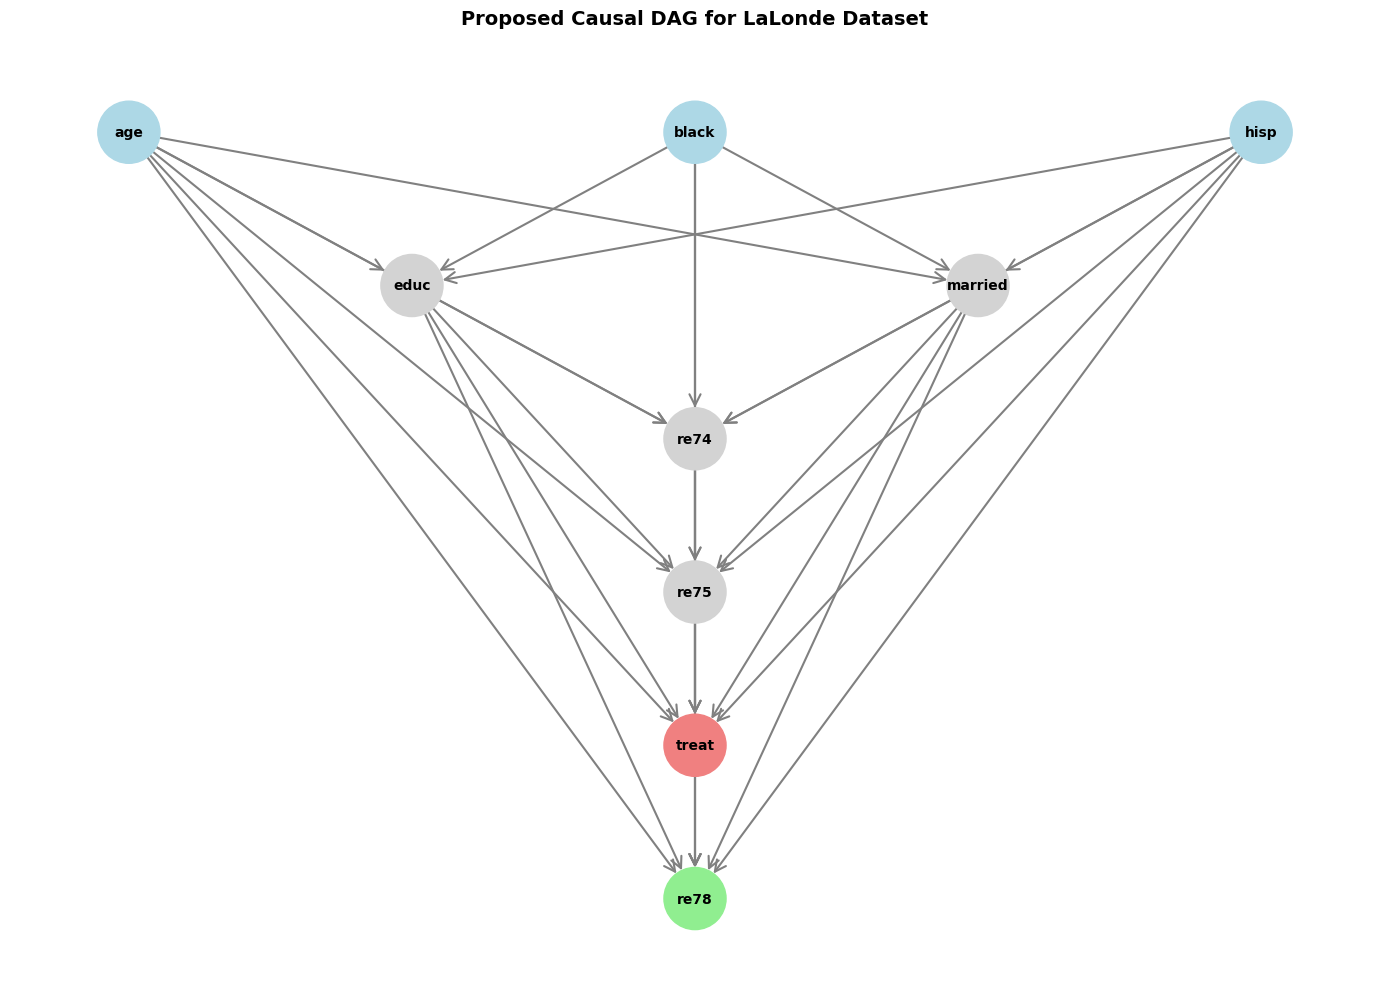

In [6]:
visualize_dag(dag)

## Falsification Test

The `falsify_graph` function tests whether the proposed DAG is consistent with the data by checking **Local Markov Conditions (LMCs)**:

> For each node X with parents Pa_X, X should be conditionally independent of all its non-descendants given Pa_X.

The test works as follows:
1. Count LMC violations in the given DAG using kernel-based conditional independence tests
2. Generate random node-permuted DAGs and count their LMC violations
3. Compare: if the given DAG has significantly fewer violations than random DAGs, it is **not falsified**

The result has two key attributes:
- **`falsifiable`**: The DAG makes testable predictions (lies in a different Markov Equivalence Class than most permuted DAGs)
- **`falsified`**: The DAG is falsifiable AND has more violations than expected by chance

**Note**: This test can take several minutes due to kernel-based conditional independence tests on 2,675 observations.

In [7]:
# Run falsification test on the proposed DAG
dag_columns = list(dag.nodes)
dag_data = data[dag_columns]

print("Running falsification test (this may take a few minutes)...\n")

result = falsify_graph(
    dag,
    dag_data,
    show_progress_bar=True,
)

print(result)

Running falsification test (this may take a few minutes)...



Test permutations of given graph: 100%|██████████| 20/20 [00:40<00:00,  2.02s/it]

+-------------------------------------------------------------------------------------------------------+
|                                         Falsification Summary                                         |
+-------------------------------------------------------------------------------------------------------+
| The given DAG is informative because 0 / 20 of the permutations lie in the Markov                     |
| equivalence class of the given DAG (p-value: 0.00).                                                   |
| The given DAG violates 6/8 LMCs and is better than 60.0% of the permuted DAGs (p-value: 0.40).        |
| Based on the provided significance level (0.05) and because the DAG is informative,                   |
| we reject the DAG.                                                                                    |
+-------------------------------------------------------------------------------------------------------+


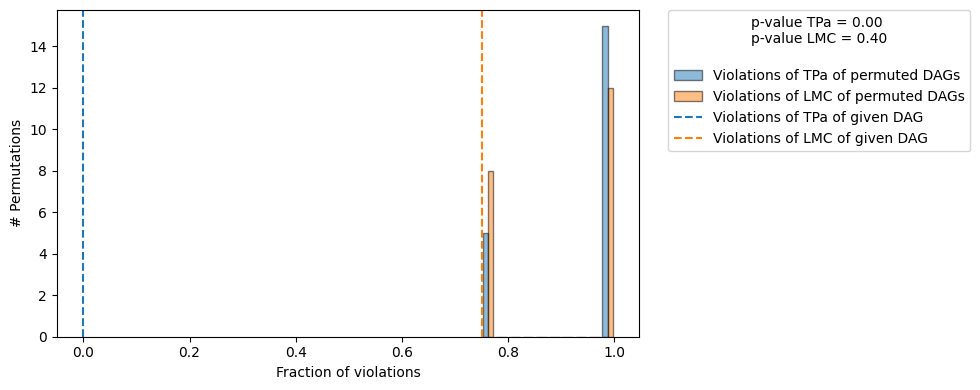

In [8]:
# Visualize the distribution of LMC violations
plot_evaluation_results(result, figsize=(10, 4))

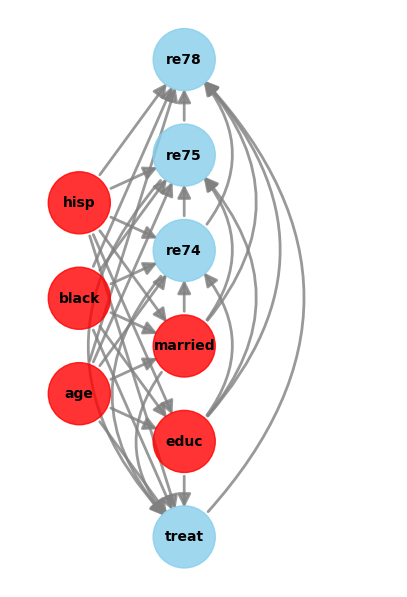

In [9]:
# Plot which nodes have LMC violations (if any)
plot_local_insights(dag, result)

## Getting Suggestions for DAG Correction

Since the proposed DAG was falsified, we can ask DoWhy to suggest corrections. When run with `suggestions=True`, `falsify_graph` tests for **causal minimality** violations:

> For each edge X → Y, test if X is conditionally independent of Y given all other parents of Y. If yes, the edge is redundant and can be removed.

**Important limitation**: Suggestions can only **remove spurious edges**, not add missing ones. If the DAG is falsified due to missing confounders, suggestions won't help—you'll need domain knowledge to identify them.

In [10]:
# Re-run falsification with suggestions enabled
print("Running falsification with suggestions (this may take longer)...\n")

result_with_suggestions = falsify_graph(
    dag,
    dag_data,
    suggestions=True,  # Enable causal minimality testing
    show_progress_bar=True,
)

print(result_with_suggestions)

Running falsification with suggestions (this may take longer)...

+-------------------------------------------------------------------------------------------------------+
|                                         Falsification Summary                                         |
+-------------------------------------------------------------------------------------------------------+
| The given DAG is informative because 0 / 20 of the permutations lie in the Markov                     |
| equivalence class of the given DAG (p-value: 0.00).                                                   |
| The given DAG violates 6/8 LMCs and is better than 35.0% of the permuted DAGs (p-value: 0.65).        |
| Based on the provided significance level (0.05) and because the DAG is informative,                   |
| we reject the DAG.                                                                                    |
+-------------------------------------------------------------------------------------

In [11]:
# Apply the suggested corrections
from dowhy.gcm.falsify import apply_suggestions

corrected_dag = apply_suggestions(dag, result_with_suggestions)

print(f"Original DAG: {dag.number_of_edges()} edges")
print(f"Corrected DAG: {corrected_dag.number_of_edges()} edges")
print(f"Edges removed: {dag.number_of_edges() - corrected_dag.number_of_edges()}")

# Show which edges were removed
removed_edges = set(dag.edges()) - set(corrected_dag.edges())
if removed_edges:
    print(f"\nRemoved edges (violate causal minimality):")
    for edge in sorted(removed_edges):
        print(f"  {edge[0]} → {edge[1]}")
else:
    print("\nNo edges removed - all edges are necessary.")

Original DAG: 32 edges
Corrected DAG: 23 edges
Edges removed: 9

Removed edges (violate causal minimality):
  age → re75
  black → re75
  black → re78
  hisp → married
  hisp → re75
  hisp → re78
  hisp → treat
  married → re75
  treat → re78


In [12]:
# Test the corrected DAG
if corrected_dag.number_of_edges() < dag.number_of_edges():
    print("Testing the corrected DAG...\n")
    corrected_result = falsify_graph(
        corrected_dag,
        dag_data,
        show_progress_bar=True,
    )
    print(corrected_result)
    
else:
    print("\nThe corrected DAG is identical to the original - no redundant edges found.")
    print("The falsification may be due to missing edges rather than spurious ones.")

Testing the corrected DAG...

+-------------------------------------------------------------------------------------------------------+
|                                         Falsification Summary                                         |
+-------------------------------------------------------------------------------------------------------+
| The given DAG is informative because 0 / 20 of the permutations lie in the Markov                     |
| equivalence class of the given DAG (p-value: 0.00).                                                   |
| The given DAG violates 6/19 LMCs and is better than 100.0% of the permuted DAGs (p-value: 0.00).      |
| Based on the provided significance level (0.05) and because the DAG is informative,                   |
| we do not reject the DAG.                                                                             |
+-------------------------------------------------------------------------------------------------------+


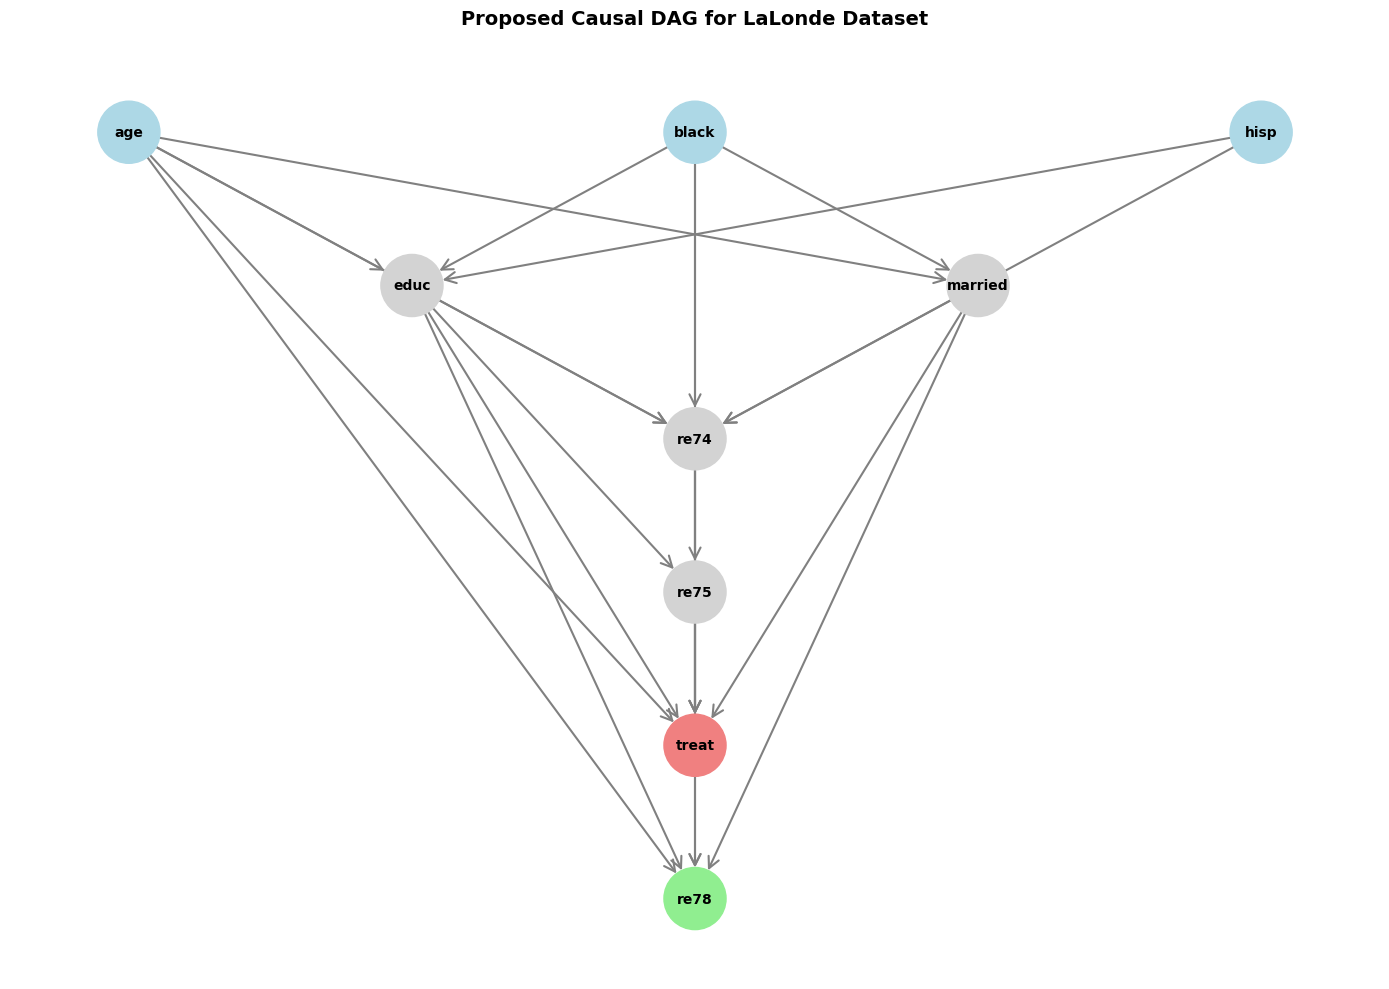

In [13]:
visualize_dag(corrected_dag)

## Interpretation

The falsification result tells us whether the data contradicts our proposed causal structure:

- **Not falsified**: The conditional independencies implied by the DAG hold in the data. This does NOT prove the DAG is correct—only that the data is consistent with it. Many other DAGs might also be consistent.

- **Falsified**: The DAG makes predictions that are violated by the data, suggesting the causal structure is incorrect.

- **Not falsifiable**: The DAG doesn't make enough testable predictions (most permuted DAGs are in the same Markov Equivalence Class), so the test lacks power.

The p-value represents the fraction of random DAGs with equal or more LMC violations than our proposed DAG. A low p-value (< 0.05) means our DAG performs significantly better than random, supporting (but not proving) the hypothesized causal structure.

### About the Suggestions

If DoWhy suggested removing edges, those edges violate **causal minimality**—they are redundant given other paths in the graph. However, if no edges were suggested for removal, the falsification is likely due to **missing edges** that should be added based on domain knowledge.

## Summary

This notebook tested whether our proposed causal DAG for the LaLonde dataset is consistent with observational data:

1. **Proposed DAG** (without deterministic variables): We encoded domain knowledge about labor market dynamics—demographics cause education and earnings, which confound treatment selection, which affects outcomes. The falsification test evaluates whether this structure is consistent with the data.

2. **Wrong DAG** (reversed causation): A deliberately incorrect DAG with `re78 → treat` should be caught by the falsification test, demonstrating the method's ability to detect structural errors.

3. **Deterministic variables**: Including `u74`, `u75`, and `nodegr` introduces spurious violations because kernel-based independence tests cannot handle deterministic relationships. This highlights the importance of careful variable selection for graph falsification.

4. **Interpretation**: Graph falsification is a **necessary but not sufficient** test of a causal model. Passing the test means the data doesn't contradict the graph, not that the graph is uniquely correct. Other DAGs in the same Markov Equivalence Class would also pass.

### Connection to Previous Notebooks

While notebooks 01-03 estimated treatment effects using matching and metalearners, this notebook tests the **structural assumptions** that underlie those estimates. The confounding relationships encoded in this DAG (demographics and earnings → treatment) are exactly what methods like propensity score matching and doubly robust estimation attempt to control for.